# AUC-ROC Analysis
Reuses the cached prediction probabilities from the SigTest notebooks -- no
models, no GPU needed. Computes multi-class AUC (One-vs-Rest) for all 6
single models plus the proposed ensemble, per-class AUC for the proposed
ensemble, and a multi-class ROC curve figure.

## Cell 1 — Setup + load cached predictions

In [1]:
import numpy as np
import pandas as pd
import json as jsonlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')
with open(f'{cache}/class_names.json') as f:
    class_names = jsonlib.load(f)

num_classes = len(class_names)
print("Loaded. Test set size:", len(true_labels), "| Classes:", num_classes)

Mounted at /content/drive
Loaded. Test set size: 2538 | Classes: 12


## Cell 2 — Macro & weighted AUC for all models + proposed ensemble

In [2]:
all_models = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
    "Proposed Ensemble": ensemble_probs,
}

auc_rows = []
for name, probs in all_models.items():
    macro_auc = roc_auc_score(true_labels, probs, multi_class='ovr', average='macro')
    weighted_auc = roc_auc_score(true_labels, probs, multi_class='ovr', average='weighted')
    auc_rows.append({"Model": name, "Macro AUC": round(macro_auc, 4), "Weighted AUC": round(weighted_auc, 4)})

auc_df = pd.DataFrame(auc_rows)
print(auc_df.to_string(index=False))

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
auc_df.to_csv(f'{output_folder}/auc_summary.csv', index=False)
print(f"\nSaved to: {output_folder}/auc_summary.csv")

            Model  Macro AUC  Weighted AUC
             Swin     0.9998        0.9998
              ViT     0.9998        0.9997
            LeViT     0.9987        0.9986
         ResNet50     0.9995        0.9995
      DenseNet121     0.9994        0.9994
   EfficientNetB0     0.9995        0.9995
Proposed Ensemble     0.9998        0.9998

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/auc_summary.csv


## Cell 3 — Per-class AUC for the proposed ensemble

In [3]:
y_true_bin = label_binarize(true_labels, classes=range(num_classes))

per_class_auc = []
for i, cls in enumerate(class_names):
    cls_auc = roc_auc_score(y_true_bin[:, i], ensemble_probs[:, i])
    per_class_auc.append({"Class": cls, "AUC": round(cls_auc, 4)})

per_class_auc_df = pd.DataFrame(per_class_auc).sort_values("AUC")
print(per_class_auc_df.to_string(index=False))
per_class_auc_df.to_csv(f'{output_folder}/auc_per_class.csv', index=False)

                     Class    AUC
           Rice_Brown_Spot 0.9995
          Corn_Leaf_Blight 0.9996
           Rice_Leaf_Blast 0.9996
             Wheat_Healthy 0.9996
       Corn_Gray_Leaf_Spot 0.9997
Rice_Bacterial_Leaf_Blight 0.9999
          Wheat_Brown_Rust 0.9999
              Rice_Healthy 0.9999
          Corn_Common_Rust 1.0000
              Corn_Healthy 1.0000
          Wheat_Loose_Smut 1.0000
         Wheat_Yellow_Rust 1.0000


## Cell 4 — Multi-class ROC curve (proposed ensemble)
One curve per class (One-vs-Rest), paper-sized figure.

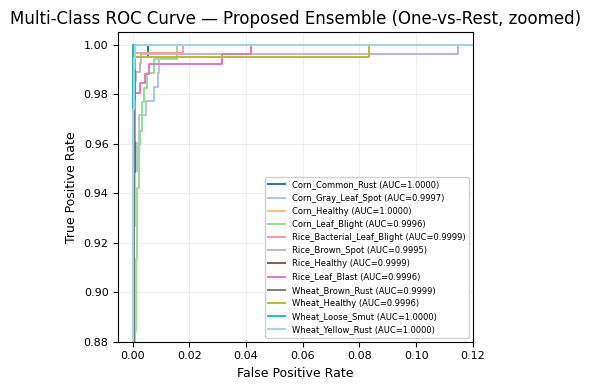

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/roc_curve_multiclass_zoomed.png

Per-class AUC (4 decimal places):
  Rice_Brown_Spot                0.9995
  Rice_Leaf_Blast                0.9996
  Corn_Leaf_Blight               0.9996
  Wheat_Healthy                  0.9996
  Corn_Gray_Leaf_Spot            0.9997
  Wheat_Brown_Rust               0.9999
  Rice_Bacterial_Leaf_Blight     0.9999
  Rice_Healthy                   0.9999
  Corn_Common_Rust               1.0000
  Wheat_Yellow_Rust              1.0000
  Corn_Healthy                   1.0000
  Wheat_Loose_Smut               1.0000


In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4))
colors = plt.cm.tab20(np.linspace(0, 1, num_classes))

class_aucs = []
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], ensemble_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    class_aucs.append(roc_auc_i)
    ax.plot(fpr, tpr, color=colors[i], linewidth=1.4, label=f"{cls} (AUC={roc_auc_i:.4f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)

# Zoom into the top-left corner -- with this many near-perfect classes, the
# full [0,1]x[0,1] view just clusters everything into one corner. Adjust the
# limits below if your curves still get cut off or still look bunched.
ax.set_xlim(-0.005, 0.12)
ax.set_ylim(0.88, 1.005)

ax.set_xlabel('False Positive Rate', fontsize=9)
ax.set_ylabel('True Positive Rate', fontsize=9)
ax.set_title('Multi-Class ROC Curve — Proposed Ensemble (One-vs-Rest, zoomed)', fontsize=12)
ax.tick_params(labelsize=8)
ax.legend(fontsize=6, loc='lower right', ncol=1, framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{output_folder}/roc_curve_multiclass_zoomed.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/roc_curve_multiclass_zoomed.png")

print("\nPer-class AUC (4 decimal places):")
for cls, a in sorted(zip(class_names, class_aucs), key=lambda t: t[1]):
    print(f"  {cls:30s} {a:.4f}")